# 01 — Data Exploration

**Project:** Plate Heat Exchanger (PHE) Performance Analysis and Prediction

**Goal of this notebook:** understand what the RareTechSEA1C-60 dataset actually contains *before* any modelling:

1. Load the data and check size, types, missing values and duplicates
2. Work out what each column means by reconstructing it from the other columns
3. Identify which stream is hot and which is cold in each row
4. Look at the distributions of the main operating, design and performance variables

**About the data:** 59,265 cases generated by feeding thermo-fluid operating conditions into commercial PHE design software (source: RareTechSEA, Kaggle).
This is *software-generated design data*, not plant measurements.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)

# Consistent, quiet plot style
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": "#e6e5e0",
    "grid.linewidth": 0.6,
    "axes.edgecolor": "#8a8984",
    "axes.labelcolor": "#2b2b2a",
    "xtick.color": "#52514e",
    "ytick.color": "#52514e",
    "font.size": 10,
})
BLUE, ORANGE = "#2a78d6", "#eb6834"   # hot = orange, cold = blue throughout the project

DATA_PATH = "../data/RareTechSEA1C-60.csv"
FIG_DIR = "../figures/"

# Create output folders if they do not exist yet (Git does not store empty folders)
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs("../data/processed", exist_ok=True)

## 1. Load and inspect

In [2]:
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()

Shape: (59265, 32)


,Thickness,Temp1In,Temp1Out,Temp2In,Temp2Out,Fluid1,Fluid2,Q,Qr,Lmtd,Theta1,Theta2,m1,m2,dP1,dP2,V1In,V2In,A,M,Ae,Me,NP,AdNP,NuP,Ar,(UF)t,(UF)r,mr,Pr,ln(mr),ln(Pr)
0,0.4,68,63,57,67.98,21,2,409.91,68.32,1.011,4.95,10.87,39.16,8.88,31.12,0.06,0.923,0.193,272.00,0.0,271.00,0.0,544,0.50,6.0,45.33,1490.8,1490.8,4.41,559.12,1.48,6.33
1,0.4,41,34,30,40.91,43,15,552.38,276.19,1.024,6.84,10.66,41.60,12.06,65.93,0.91,0.482,0.124,661.50,1.0,655.50,1.0,441,1.50,2.0,330.75,815.5,815.5,3.45,72.22,1.24,4.28
2,0.4,69,76,80,69.09,44,33,383.84,76.77,1.035,6.77,10.54,27.32,17.48,21.08,20.43,0.358,0.230,336.66,0.0,335.42,0.0,543,0.62,5.0,67.33,1102.0,1102.0,1.56,1.03,0.45,0.03
3,0.4,65,71,76,65.06,39,37,407.14,50.89,1.100,5.45,9.95,34.05,18.59,13.83,7.38,0.626,0.343,260.00,0.0,259.00,0.0,520,0.50,8.0,32.50,1423.2,1423.2,1.83,1.87,0.61,0.63
4,0.4,61,56,50,60.97,17,9,272.18,68.05,1.125,4.45,9.75,26.00,12.70,80.97,42.66,0.409,0.207,306.28,12.0,305.04,12.2,494,0.62,4.0,76.57,790.2,790.2,2.05,1.90,0.72,0.64


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 59265 entries, 0 to 59264
Data columns (total 32 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Thickness  59265 non-null  float64
 1   Temp1In    59265 non-null  int64  
 2   Temp1Out   59265 non-null  int64  
 3   Temp2In    59265 non-null  int64  
 4   Temp2Out   59265 non-null  float64
 5   Fluid1     59265 non-null  int64  
 6   Fluid2     59265 non-null  int64  
 7   Q          59265 non-null  float64
 8   Qr         59265 non-null  float64
 9   Lmtd       59265 non-null  float64
 10  Theta1     59265 non-null  float64
 11  Theta2     59265 non-null  float64
 12  m1         59265 non-null  float64
 13  m2         59265 non-null  float64
 14  dP1        59265 non-null  float64
 15  dP2        59265 non-null  float64
 16  V1In       59265 non-null  float64
 17  V2In       59265 non-null  float64
 18  A          59265 non-null  float64
 19  M          59265 non-null  float64
 20  Ae         59265 

In [4]:
print("Missing values (total):", df.isna().sum().sum())
print("Exact duplicate rows   :", df.duplicated().sum())
df[df.duplicated(keep=False)]

Missing values (total): 0
Exact duplicate rows   : 2


,Thickness,Temp1In,Temp1Out,Temp2In,Temp2Out,Fluid1,Fluid2,Q,Qr,Lmtd,Theta1,Theta2,m1,m2,dP1,dP2,V1In,V2In,A,M,Ae,Me,NP,AdNP,NuP,Ar,(UF)t,(UF)r,mr,Pr,ln(mr),ln(Pr)
15698,0.4,49,64,73,57.23,33,15,1429.04,1429.04,8.609,1.74,1.83,48.69,21.60,25.94,2.40,3.172,1.250,351.54,0.0,350.30,0.0,567,0.62,1.0,351.54,472.2,472.2,2.25,10.82,0.81,2.38
15699,0.4,49,64,73,57.23,33,15,1429.04,1429.04,8.609,1.74,1.83,48.69,21.60,25.94,2.40,3.172,1.250,351.54,0.0,350.30,0.0,567,0.62,1.0,351.54,472.2,472.2,2.25,10.82,0.81,2.38
41481,0.4,39,68,75,70.26,39,41,169.76,169.76,16.212,1.79,0.29,3.01,17.85,56.95,42.52,0.442,2.632,23.04,9.0,22.56,9.1,96,0.24,1.0,23.04,454.5,454.5,0.17,1.34,-1.78,0.29
41482,0.4,39,68,75,70.26,39,41,169.76,169.76,16.212,1.79,0.29,3.01,17.85,56.95,42.52,0.442,2.632,23.04,9.0,22.56,9.1,96,0.24,1.0,23.04,454.5,454.5,0.17,1.34,-1.78,0.29


There are **no missing values**. There are **2 exact duplicate rows** (two pairs of identical cases).
Since the data come from software runs, an exact duplicate is the same design case recorded twice and adds no information — it would only give that case double weight in modelling. The duplicates are removed.

In [5]:
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (59263, 32)


## 2. What does each column mean?

The dataset comes without a full data dictionary, so each column's meaning is **reconstructed from the other columns**.
If a formula reproduces a column for (almost) every row, that interpretation is accepted.

The check below reports the fraction of rows where the proposed formula matches the column within 1–2 % (rounding in the CSV causes small differences).

In [6]:
def match_rate(calculated, reported, rel_tol=0.02, abs_tol=0.02):
    # Fraction of rows where calculated value matches reported value within tolerance
    ok = np.isclose(calculated, reported, rtol=rel_tol, atol=abs_tol)
    return ok.mean()

checks = {
    "Qr   = Q / NuP                  (duty per unit)":        match_rate(df.Q / df.NuP, df.Qr),
    "A    = NP x AdNP                (total area)":           match_rate(df.NP * df.AdNP, df.A),
    "Ar   = A / NuP                  (area per unit)":        match_rate(df.A / df.NuP, df.Ar),
    "(UF)t = 1000 Qr / (Ar x Lmtd)    (overall U, W/m2K)":    match_rate(1000 * df.Qr / (df.Ar * df.Lmtd), df["(UF)t"]),
    "(UF)r = (UF)t                   (identical columns)":    (df["(UF)t"] == df["(UF)r"]).mean(),
    "mr   = m1 / m2                  (mass-flow ratio)":      match_rate(df.m1 / df.m2, df.mr),
    "Pr   = dP1 / dP2                (pressure-drop ratio)":  match_rate(df.dP1 / df.dP2, df.Pr, rel_tol=0.05),
    "Theta1 = |T1in - T1out| / Lmtd  (stream-1 NTU)":        match_rate((df.Temp1In - df.Temp1Out).abs() / df.Lmtd, df.Theta1, rel_tol=0.05),
    "Theta2 = |T2out - T2in| / Lmtd  (stream-2 NTU)":        match_rate((df.Temp2Out - df.Temp2In).abs() / df.Lmtd, df.Theta2, rel_tol=0.05),
}
pd.Series(checks, name="match rate").to_frame().style.format("{:.1%}")

,match rate
Qr = Q / NuP (duty per unit),100.0%
A = NP x AdNP (total area),97.1%
Ar = A / NuP (area per unit),100.0%
"(UF)t = 1000 Qr / (Ar x Lmtd) (overall U, W/m2K)",100.0%
(UF)r = (UF)t (identical columns),100.0%
mr = m1 / m2 (mass-flow ratio),99.9%
Pr = dP1 / dP2 (pressure-drop ratio),100.0%
Theta1 = |T1in - T1out| / Lmtd (stream-1 NTU),100.0%
Theta2 = |T2out - T2in| / Lmtd (stream-2 NTU),100.0%


**Resulting data dictionary** (units inferred — see notebook 02 for the energy-balance check that supports kg/s and kW):

| Group | Column | Meaning |
|---|---|---|
| Operating | `Temp1In`, `Temp1Out`, `Temp2In`, `Temp2Out` | Stream inlet/outlet temperatures (°C) |
| Operating | `m1`, `m2` | Mass flow rates (kg/s) |
| Operating | `Fluid1`, `Fluid2` | Fluid ID (28 IDs; names not documented) |
| Design | `Thickness` | Plate thickness (mm) |
| Design | `AdNP` | Heat-transfer area per plate (m²) — 20 discrete plate sizes |
| Design | `NP`, `A`, `Ae` | Number of plates, total area (m²), effective area (m²) |
| Design | `NuP`, `Ar` | Number of units in parallel, area per unit |
| Performance | `Q`, `Qr` | Total heat duty (kW), duty per unit |
| Performance | `Lmtd` | Log-mean temperature difference (K) |
| Performance | `(UF)t` = `(UF)r` | Overall heat-transfer coefficient U (W/m²·K) |
| Performance | `dP1`, `dP2` | Pressure drop per stream (kPa) |
| Performance | `V1In`, `V2In` | Inlet velocities (m/s) — not yet verified |
| Derived | `Theta1`, `Theta2` | Temperature change / LMTD = NTU per side |
| Derived | `mr`, `Pr`, `ln(mr)`, `ln(Pr)` | Flow and pressure-drop ratios and their logs |
| Unclear | `M`, `Me` | Possibly design margin — not used |

**Important consequence:** `Qr`, `Ar`, `(UF)t`, `Theta`, `mr` and `Pr` are *calculated from other columns*. They must be handled carefully in machine learning to avoid target leakage.

## 3. Discrete design variables

In [7]:
for col in ["Thickness", "NuP", "AdNP"]:
    print(f"--- {col} ---")
    print(df[col].value_counts().sort_index().to_string(), "\n")
print("Distinct fluid IDs:", sorted(set(df.Fluid1) | set(df.Fluid2)))

--- Thickness ---
Thickness
0.4    50255
0.5     8709
0.6      298
0.8        1 

--- NuP ---
NuP
1.0     46637
2.0      8448
3.0      1689
4.0       935
5.0       549
6.0       355
7.0       230
8.0       167
9.0       124
10.0      129 

--- AdNP ---
AdNP
0.02      445
0.03      575
0.08      823
0.09      298
0.14     1927
0.15     1455
0.18        1
0.22    11165
0.24    10868
0.28       60
0.38        3
0.50     5129
0.62    24010
0.85      107
0.91        1
1.10        2
1.48      289
1.50     1839
1.70       74
1.84      192 

Distinct fluid IDs: [1, 2, 3, 9, 11, 12, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 33, 35, 36, 37, 39, 41, 42, 43, 44, 140, 2001, 2002]


## 4. Which stream is hot?

The original plan assumed stream 1 is always the hot stream. That needs checking: if stream 1 is hot, its temperature must drop (`Temp1In > Temp1Out`).

In [8]:
stream1_hot = df.Temp1In > df.Temp2In
stream1_cools = df.Temp1In > df.Temp1Out

print(f"Rows where stream 1 has the higher inlet temperature: {stream1_hot.mean():.1%}")
print(f"Rows where stream 1 temperature decreases:            {stream1_cools.mean():.1%}")
print("Are these the same rows?", (stream1_hot == stream1_cools).all())

Rows where stream 1 has the higher inlet temperature: 53.0%
Rows where stream 1 temperature decreases:            53.0%
Are these the same rows? True


Stream 1 is the hot stream in only about **53 %** of rows; in the other **47 %** it is the *cold* stream being heated.
Any analysis that assumes "stream 1 = hot" (for example an LMTD formula written with `Temp1In - Temp2Out`) would be wrong for almost half the data.

To make the data physically consistent, every row is re-expressed in terms of **hot** and **cold** streams:

In [9]:
h = stream1_hot  # True -> stream 1 is hot

hx = pd.DataFrame({
    "Th_in":  np.where(h, df.Temp1In,  df.Temp2In),
    "Th_out": np.where(h, df.Temp1Out, df.Temp2Out),
    "Tc_in":  np.where(h, df.Temp2In,  df.Temp1In),
    "Tc_out": np.where(h, df.Temp2Out, df.Temp1Out),
    "m_hot":  np.where(h, df.m1, df.m2),
    "m_cold": np.where(h, df.m2, df.m1),
    "fluid_hot":  np.where(h, df.Fluid1, df.Fluid2),
    "fluid_cold": np.where(h, df.Fluid2, df.Fluid1),
    "dP_hot":  np.where(h, df.dP1, df.dP2),
    "dP_cold": np.where(h, df.dP2, df.dP1),
    "V_hot":   np.where(h, df.V1In, df.V2In),
    "V_cold":  np.where(h, df.V2In, df.V1In),
    "thickness": df.Thickness,
    "plate_area": df.AdNP,
    "n_units": df.NuP,
    "NP": df.NP,
    "A": df.A,
    "Q": df.Q,
    "Lmtd": df.Lmtd,
    "U": df["(UF)t"],
    "stream1_is_hot": h,
})
hx["dT_hot"] = hx.Th_in - hx.Th_out
hx["dT_cold"] = hx.Tc_out - hx.Tc_in

print("Hot stream always cools :", (hx.dT_hot > 0).all())
print("Cold stream always heats:", (hx.dT_cold > 0).all())
print("Hot inlet > cold inlet  :", (hx.Th_in > hx.Tc_in).all())
hx.head()

Hot stream always cools : True
Cold stream always heats: True
Hot inlet > cold inlet  : True


,Th_in,Th_out,Tc_in,Tc_out,m_hot,m_cold,fluid_hot,fluid_cold,dP_hot,dP_cold,V_hot,V_cold,thickness,plate_area,n_units,NP,A,Q,Lmtd,U,stream1_is_hot,dT_hot,dT_cold
0,68,63.00,57,67.98,39.16,8.88,21,2,31.12,0.06,0.923,0.193,0.4,0.50,6.0,544,272.00,409.91,1.011,1490.8,True,5.00,10.98
1,41,34.00,30,40.91,41.60,12.06,43,15,65.93,0.91,0.482,0.124,0.4,1.50,2.0,441,661.50,552.38,1.024,815.5,True,7.00,10.91
2,80,69.09,69,76.00,17.48,27.32,33,44,20.43,21.08,0.230,0.358,0.4,0.62,5.0,543,336.66,383.84,1.035,1102.0,False,10.91,7.00
3,76,65.06,65,71.00,18.59,34.05,37,39,7.38,13.83,0.343,0.626,0.4,0.50,8.0,520,260.00,407.14,1.100,1423.2,False,10.94,6.00
4,61,56.00,50,60.97,26.00,12.70,17,9,80.97,42.66,0.409,0.207,0.4,0.62,4.0,494,306.28,272.18,1.125,790.2,True,5.00,10.97


In [10]:
hx.to_csv("../data/processed/hx_hot_cold.csv", index=False)
print("Saved:", hx.shape)

Saved: (59263, 23)


## 5. Distributions

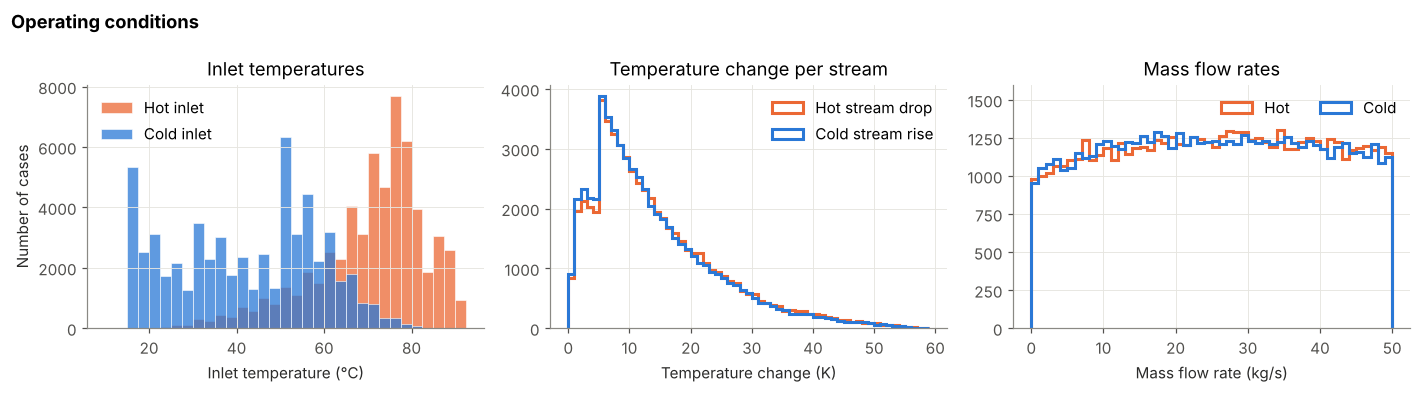

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))

ax = axes[0]
bins = np.arange(10, 95, 2.5)
ax.hist(hx.Th_in, bins=bins, color=ORANGE, alpha=0.75, label="Hot inlet", edgecolor="white", linewidth=0.5)
ax.hist(hx.Tc_in, bins=bins, color=BLUE, alpha=0.75, label="Cold inlet", edgecolor="white", linewidth=0.5)
ax.set(xlabel="Inlet temperature (°C)", ylabel="Number of cases", title="Inlet temperatures")
ax.legend(frameon=False)

ax = axes[1]
ax.hist(hx.dT_hot, bins=np.arange(0, 60, 1), histtype="step", color=ORANGE, linewidth=2, label="Hot stream drop")
ax.hist(hx.dT_cold, bins=np.arange(0, 60, 1), histtype="step", color=BLUE, linewidth=2, label="Cold stream rise")
ax.set(xlabel="Temperature change (K)", title="Temperature change per stream")
ax.legend(frameon=False)

ax = axes[2]
bins = np.arange(0, 51, 1)
ax.hist(hx.m_hot, bins=bins, histtype="step", color=ORANGE, linewidth=2, label="Hot")
ax.hist(hx.m_cold, bins=bins, histtype="step", color=BLUE, linewidth=2, label="Cold")
ax.set(xlabel="Mass flow rate (kg/s)", title="Mass flow rates", ylim=(0, 1600))
ax.legend(frameon=False, loc="upper right", ncol=2)

fig.suptitle("Operating conditions", x=0.01, ha="left", fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR + "01_operating_conditions.png", bbox_inches="tight")
plt.show()

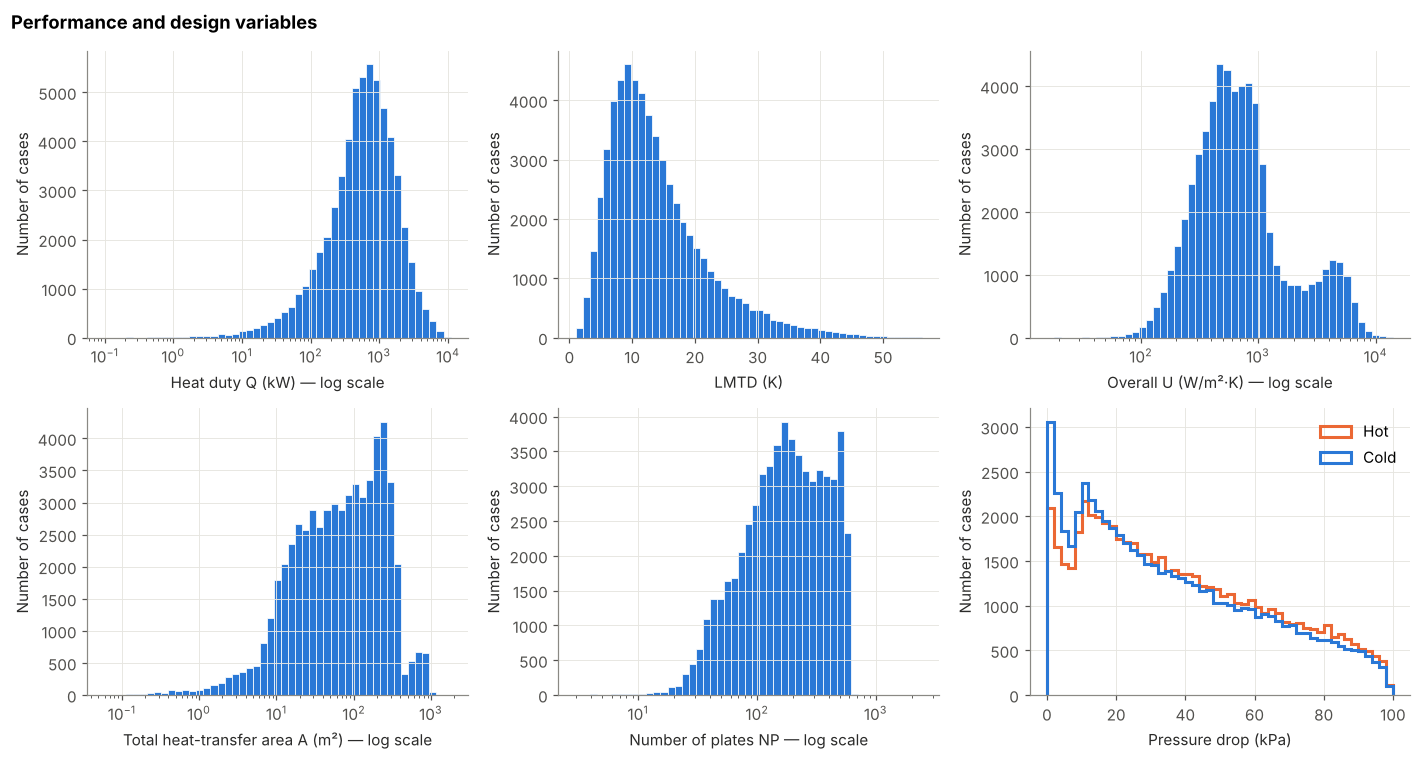

In [12]:
def log_bins(series, n=50):
    return np.logspace(np.log10(series.min()), np.log10(series.max()), n)

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
panels = [
    ("Q",    "Heat duty Q (kW)",                 True),
    ("Lmtd", "LMTD (K)",                        False),
    ("U",    "Overall U (W/m²·K)",               True),
    ("A",    "Total heat-transfer area A (m²)",  True),
    ("NP",   "Number of plates NP",              True),
]
for ax, (col, label, use_log) in zip(axes.flat, panels):
    bins = log_bins(hx[col]) if use_log else 50
    ax.hist(hx[col], bins=bins, color=BLUE, edgecolor="white", linewidth=0.5)
    if use_log:
        ax.set_xscale("log")
    ax.set(xlabel=label + (" — log scale" if use_log else ""), ylabel="Number of cases")

ax = axes.flat[5]
bins = np.arange(0, 101, 2)
ax.hist(hx.dP_hot, bins=bins, histtype="step", color=ORANGE, linewidth=2, label="Hot")
ax.hist(hx.dP_cold, bins=bins, histtype="step", color=BLUE, linewidth=2, label="Cold")
ax.set(xlabel="Pressure drop (kPa)", ylabel="Number of cases")
ax.legend(frameon=False)

fig.suptitle("Performance and design variables", x=0.01, ha="left", fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR + "01_performance_design.png", bbox_inches="tight")
plt.show()

In [13]:
key = ["Th_in", "Tc_in", "dT_hot", "dT_cold", "m_hot", "m_cold", "Q", "Lmtd", "U", "A", "NP", "dP_hot", "dP_cold"]
summary = hx[key].describe(percentiles=[0.05, 0.5, 0.95]).T
summary["skew"] = hx[key].skew()
summary.round(2)

,count,mean,std,min,5%,50%,95%,max,skew
Th_in,59263.0,70.41,12.60,23.00,45.00,73.00,88.00,90.00,-0.95
Tc_in,59263.0,41.79,16.56,15.00,15.00,43.00,67.00,81.00,-0.06
dT_hot,59263.0,14.13,10.37,0.24,2.07,11.24,35.49,58.65,1.20
dT_cold,59263.0,13.69,10.18,0.25,1.96,11.00,34.12,58.00,1.24
m_hot,59263.0,25.44,14.14,0.01,2.95,25.63,47.47,50.00,-0.03
m_cold,59263.0,25.23,14.13,0.01,2.89,25.23,47.37,50.00,-0.01
Q,59263.0,921.37,1006.48,0.10,58.97,609.72,2852.78,10865.35,2.70
Lmtd,59263.0,14.01,7.93,1.01,4.67,12.15,30.01,56.17,1.35
U,59263.0,1171.46,1468.29,15.90,192.41,630.10,4769.39,14040.00,2.59
A,59263.0,126.94,150.65,0.06,6.16,71.92,358.36,1788.00,2.44


In [14]:
# Two features in the histograms look like design-software rules rather than physics:
# (1) no pressure drop reaches 100 kPa, (2) the plate count has a sharp upper edge.
dp_max = hx[["dP_hot", "dP_cold"]].max(axis=1)
print(f"Largest pressure drop in the dataset : {dp_max.max():.2f} kPa")
print(f"Cases with either dP above 95 kPa     : {(dp_max > 95).mean():.1%}")

plates_per_unit = hx.NP / hx.n_units
print(f"Largest number of plates per unit     : {plates_per_unit.max():.0f}")
print(f"Cases split into >1 parallel unit     : {(hx.n_units > 1).mean():.1%}")

Largest pressure drop in the dataset : 98.99 kPa
Cases with either dP above 95 kPa     : 2.2%
Largest number of plates per unit     : 600
Cases split into >1 parallel unit     : 21.3%


## 6. Observations

**Data quality**
- No missing values. 2 exact duplicate rows were removed, leaving **59,263 cases**.
- Nine column definitions were reconstructed from the other columns, each matching 97–100 % of rows. `Qr`, `Ar`, `(UF)t/(UF)r`, `Theta1/2`, `mr` and `Pr` are **derived columns**, so they are leakage risks for modelling.

**Hot/cold orientation**
- Stream 1 is the hot stream in only **53 %** of cases. After re-expressing every row as hot/cold, the hot stream always cools and the cold stream always heats. The data are physically consistent once orientation is fixed.

**Operating window**
- Hot inlets span 23–90 °C (median 73 °C) and cold inlets 15–81 °C (median 43 °C), so this is a low-temperature, liquid–liquid service range.
- Mass flows are spread almost **uniformly** from 0 to 50 kg/s for both streams. Real plant data would cluster around normal operating points; a flat distribution is a sign of a systematic sampling design by the dataset creator.

**Performance and design variables**
- Q, U and A are strongly right-skewed and span 4–5 orders of magnitude. A model trained on raw values would be dominated by the largest exchangers, so log-transformed targets should be considered in notebook 03.
- **U is bimodal**: a main peak around 300–1,000 W/m²·K and a second peak around 3,000–6,000 W/m²·K. A likely cause is fluid type (water-like fluids have much higher thermal conductivity than oils). This is tested in notebook 02.

**Design-software rules visible in the data**
- No pressure drop reaches 100 kPa (maximum 98.99 kPa). This suggests the software designs to an **allowable pressure-drop limit of about 100 kPa** — the hydraulic constraint is built into the data.
- The number of plates per unit never exceeds **600**. Larger duties are split into parallel units (21 % of cases). Any model of plate count must respect this rule.

**Next (notebook 02):** check the energy balance (Q = m·cp·ΔT), recompute the counter-current LMTD from the four temperatures, explain the two U modes using fluid type, and examine the flow-rate vs pressure-drop trade-off.